# Diversity VS Performances

This notebook quantify the importance of diversity compare to performances.

Results are explained in Section 4.6.

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
from utils import compute_shap_similarity_pearson, load_nested_results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.metrics import average_precision_score
from scipy.stats import rankdata

In [4]:
all_results = load_nested_results("results_limepdp")

In [5]:
dataset_names = list(all_results.keys())
models_names = sorted(list(all_results[dataset_names[0]].keys() - {"ground_truth"}))

2_annthyroid


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature         VIF
0  Indiv_Perf_1    1.473415
1  Indiv_Perf_2    1.580055
2  Indiv_Perf_3    1.330855
3     Diversity    1.205834
4     intercept  105.144832


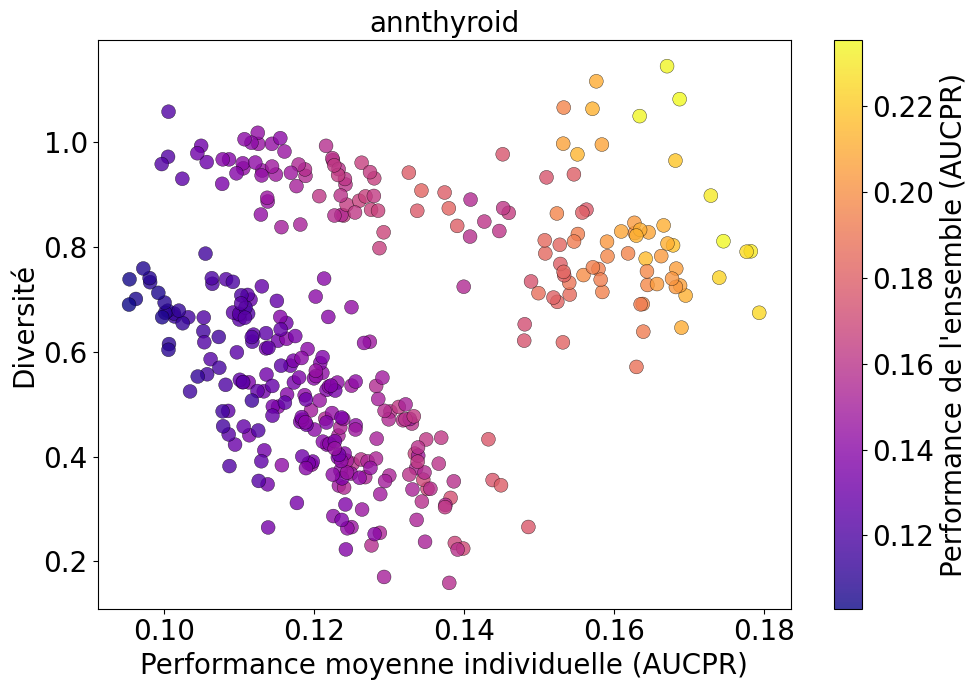

4_breastw


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature          VIF
0  Indiv_Perf_1     1.338785
1  Indiv_Perf_2     1.607538
2  Indiv_Perf_3     1.550604
3     Diversity     1.345532
4     intercept  1498.268082


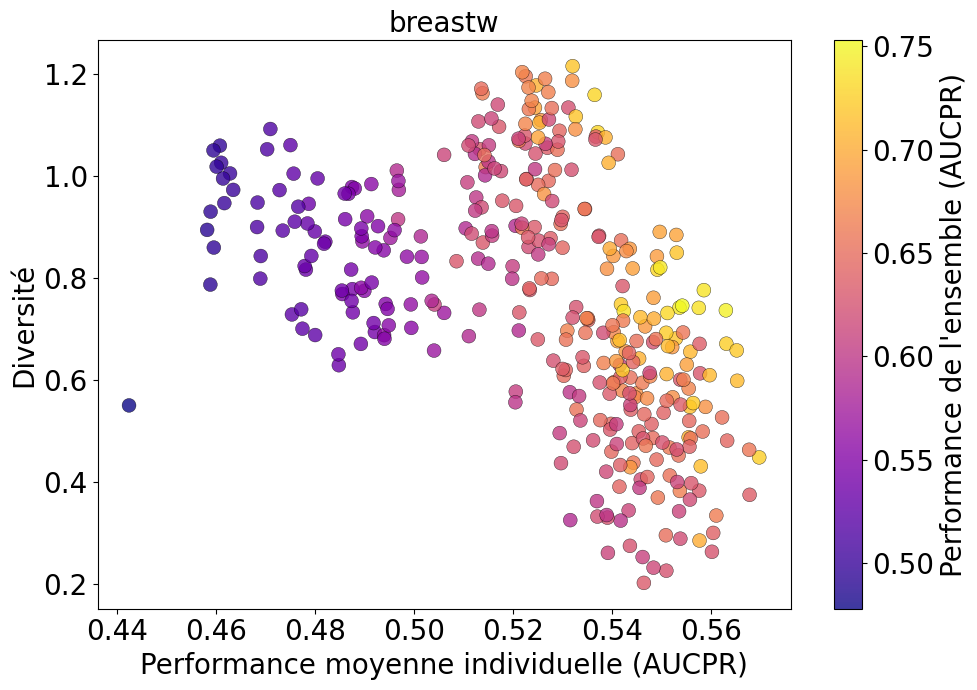

14_glass


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature         VIF
0  Indiv_Perf_1    1.461793
1  Indiv_Perf_2    1.341994
2  Indiv_Perf_3    1.113020
3     Diversity    1.212581
4     intercept  321.019237


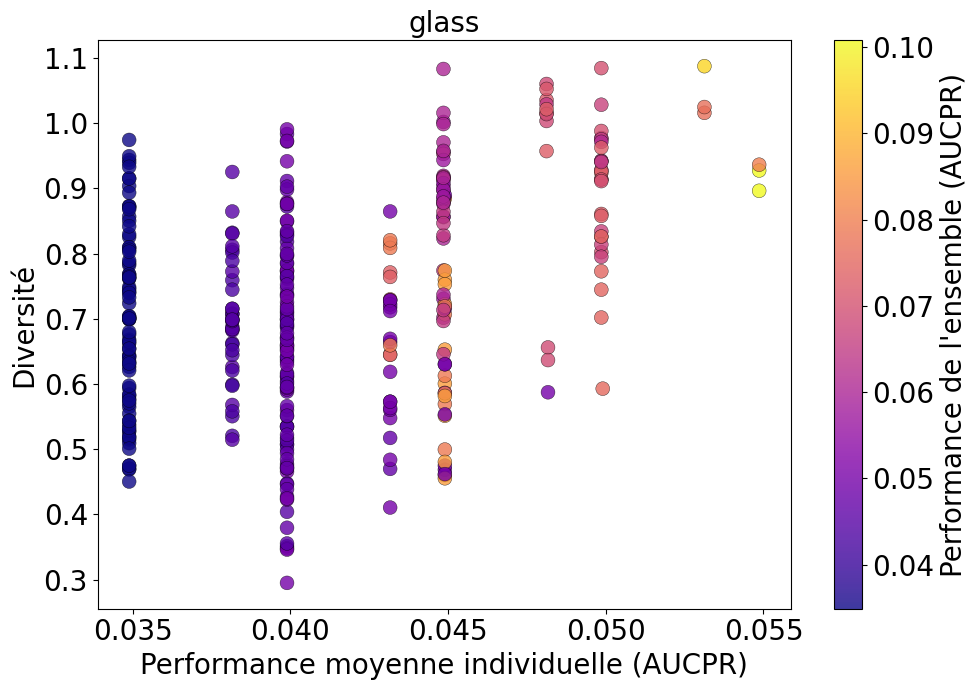

15_Hepatitis


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature         VIF
0  Indiv_Perf_1    1.367880
1  Indiv_Perf_2    1.733298
2  Indiv_Perf_3    2.416274
3     Diversity    2.135368
4     intercept  104.860965


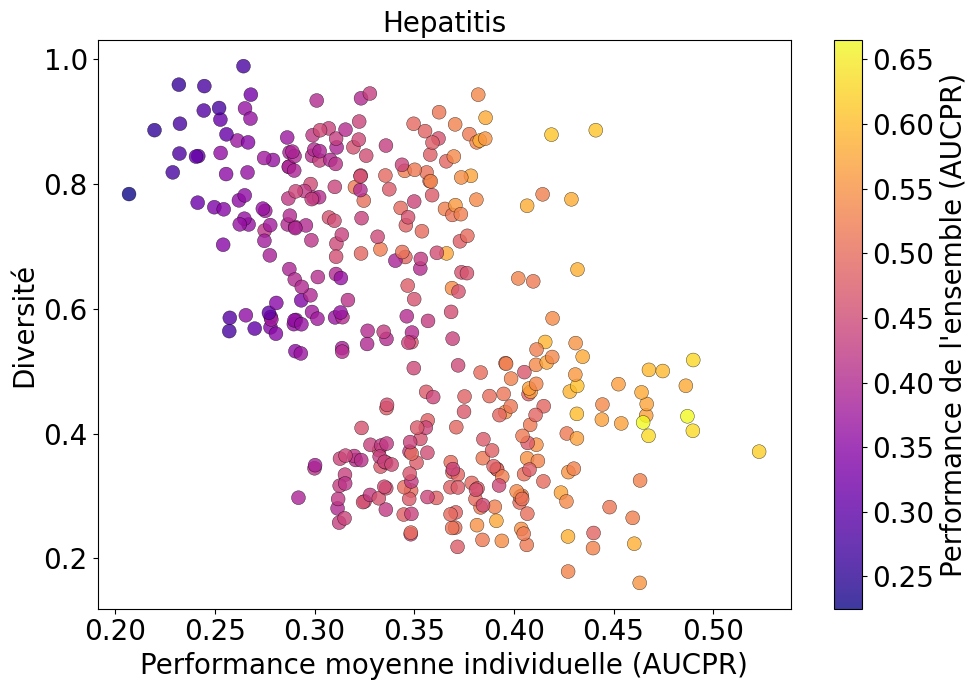

21_Lymphography


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature         VIF
0  Indiv_Perf_1    2.645687
1  Indiv_Perf_2    1.519881
2  Indiv_Perf_3    1.289003
3     Diversity    2.497154
4     intercept  370.132787


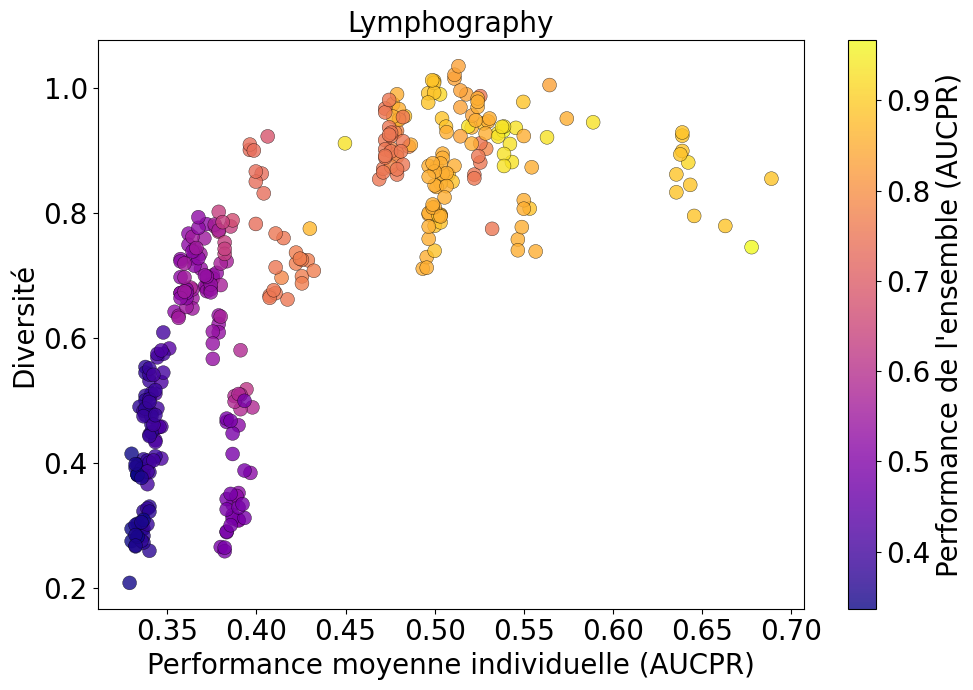

23_mammography


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature        VIF
0  Indiv_Perf_1   1.293336
1  Indiv_Perf_2   1.726215
2  Indiv_Perf_3   1.407730
3     Diversity   1.180680
4     intercept  54.281491


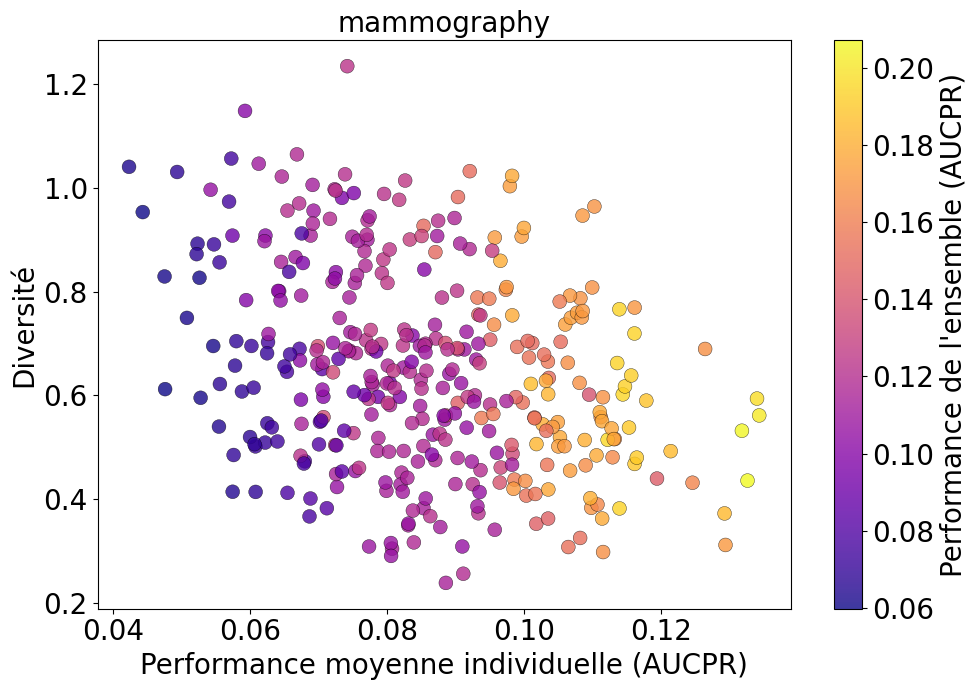

27_PageBlocks


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature         VIF
0  Indiv_Perf_1    1.548979
1  Indiv_Perf_2    1.943773
2  Indiv_Perf_3    1.565565
3     Diversity    1.292558
4     intercept  122.244179


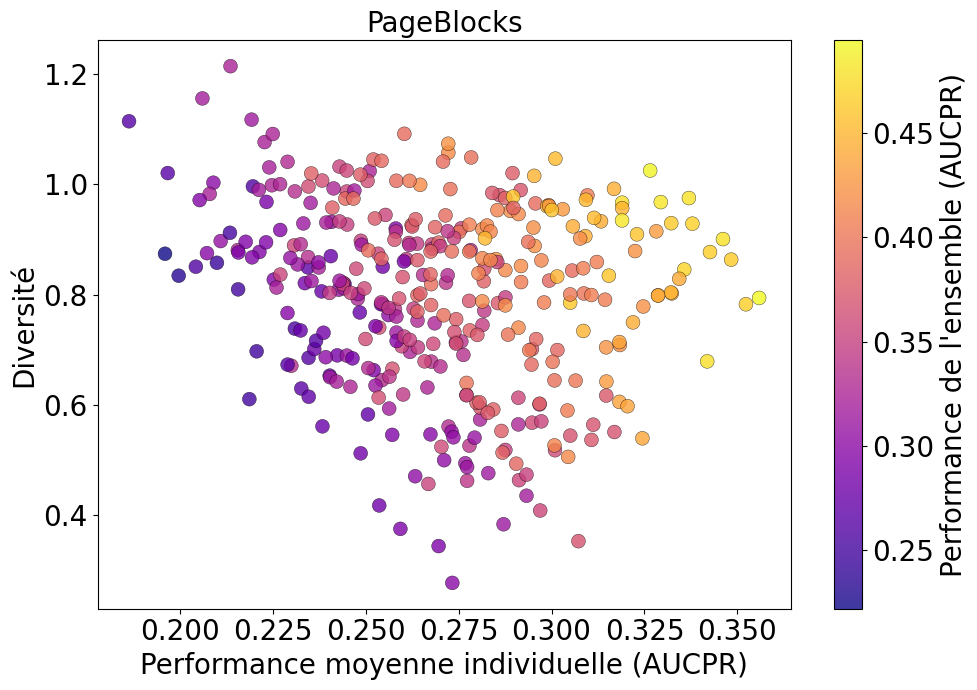

29_Pima


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature          VIF
0  Indiv_Perf_1     1.460253
1  Indiv_Perf_2     1.700489
2  Indiv_Perf_3     1.319091
3     Diversity     1.207733
4     intercept  2586.665670


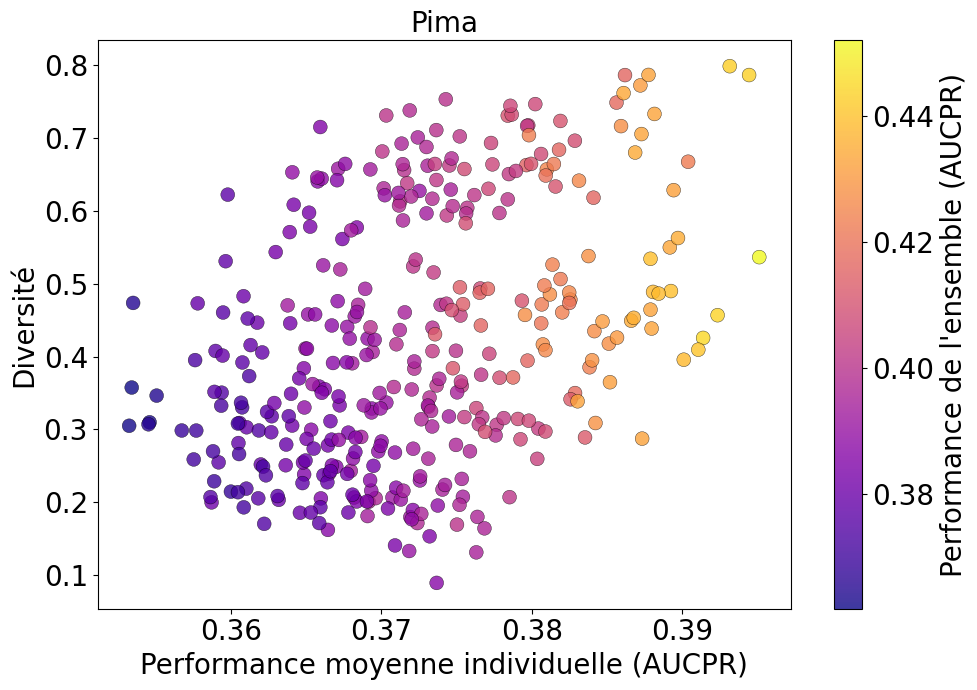

37_Stamps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature        VIF
0  Indiv_Perf_1   2.196856
1  Indiv_Perf_2   1.726471
2  Indiv_Perf_3   1.428983
3     Diversity   1.757790
4     intercept  34.604592


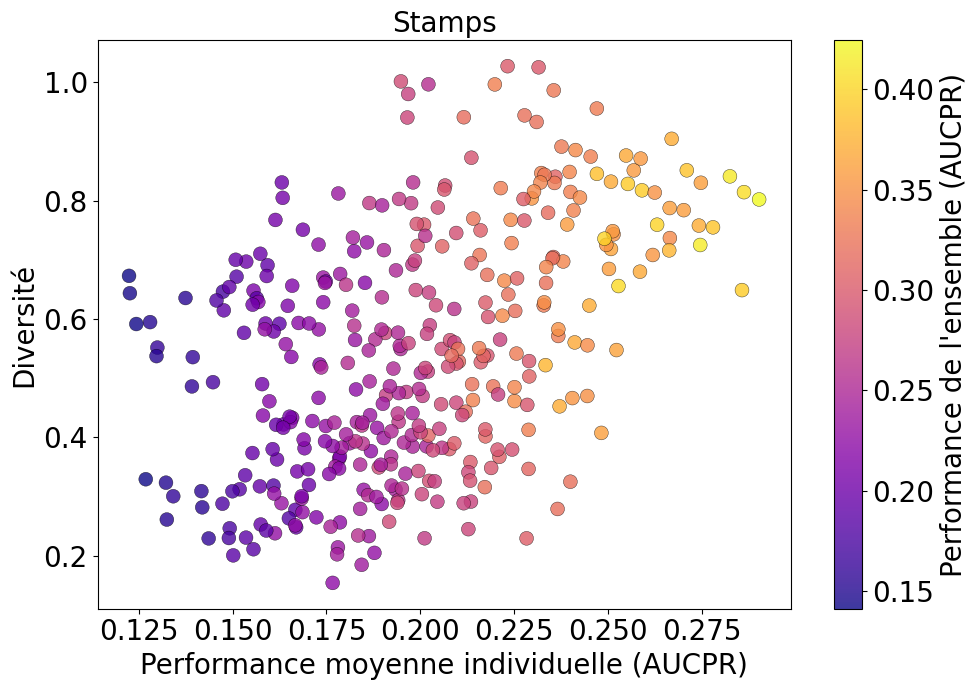

38_thyroid


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature        VIF
0  Indiv_Perf_1   1.398099
1  Indiv_Perf_2   1.684210
2  Indiv_Perf_3   2.235630
3     Diversity   1.808608
4     intercept  81.090401


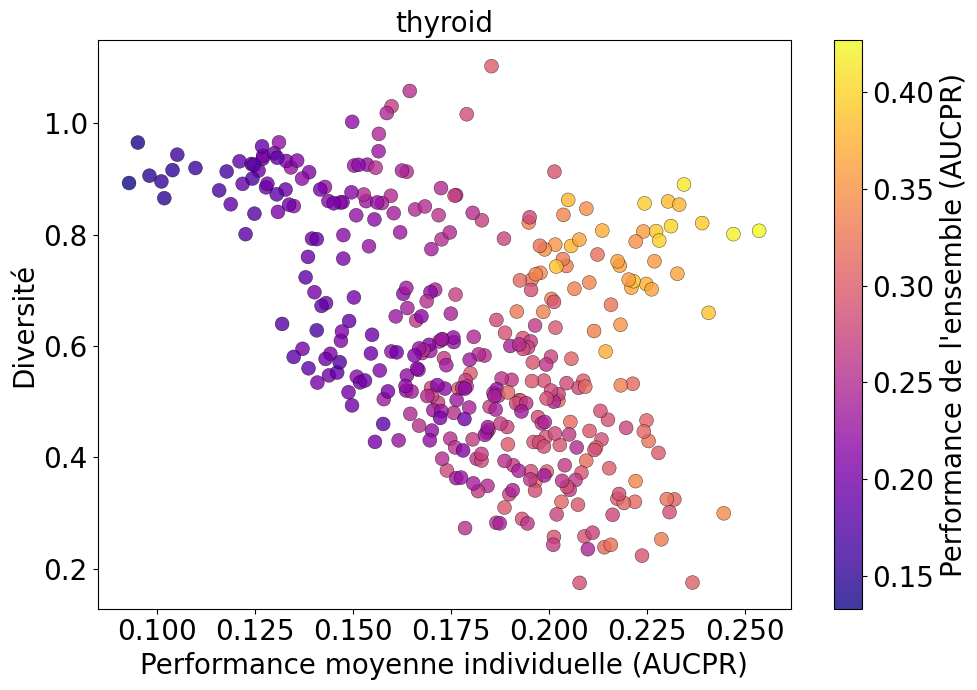

39_vertebral


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature           VIF
0  Indiv_Perf_1      1.269291
1  Indiv_Perf_2      1.462407
2  Indiv_Perf_3      1.280529
3     Diversity      1.078988
4     intercept  19362.795533


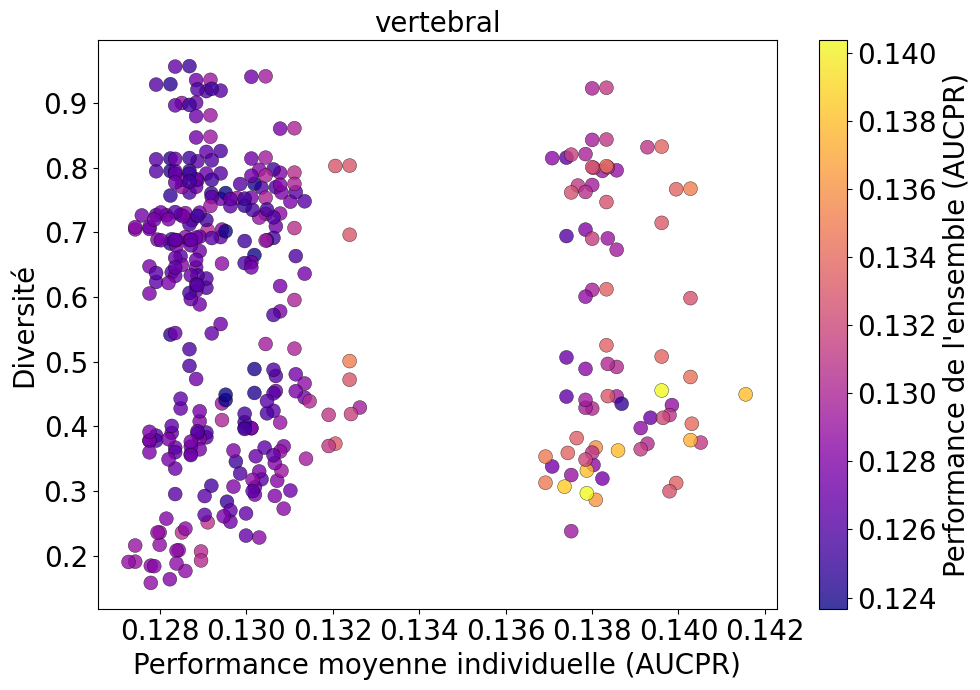

40_vowels


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature        VIF
0  Indiv_Perf_1   1.345365
1  Indiv_Perf_2   1.656060
2  Indiv_Perf_3   1.931579
3     Diversity   1.687563
4     intercept  45.664478


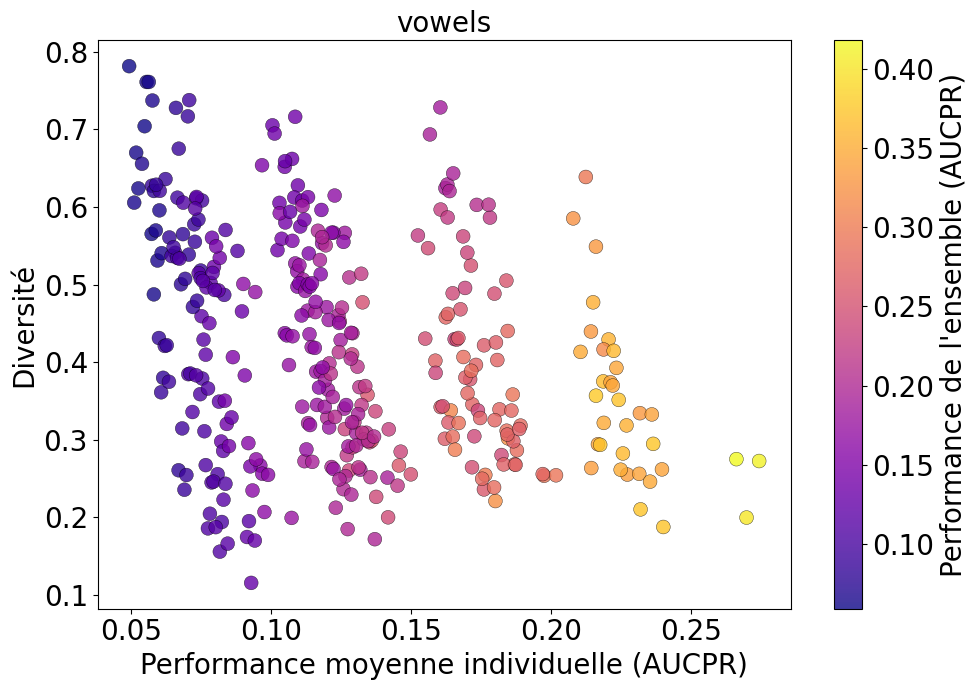

42_WBC


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature         VIF
0  Indiv_Perf_1    1.463620
1  Indiv_Perf_2    1.965308
2  Indiv_Perf_3    1.222871
3     Diversity    1.465685
4     intercept  182.524845


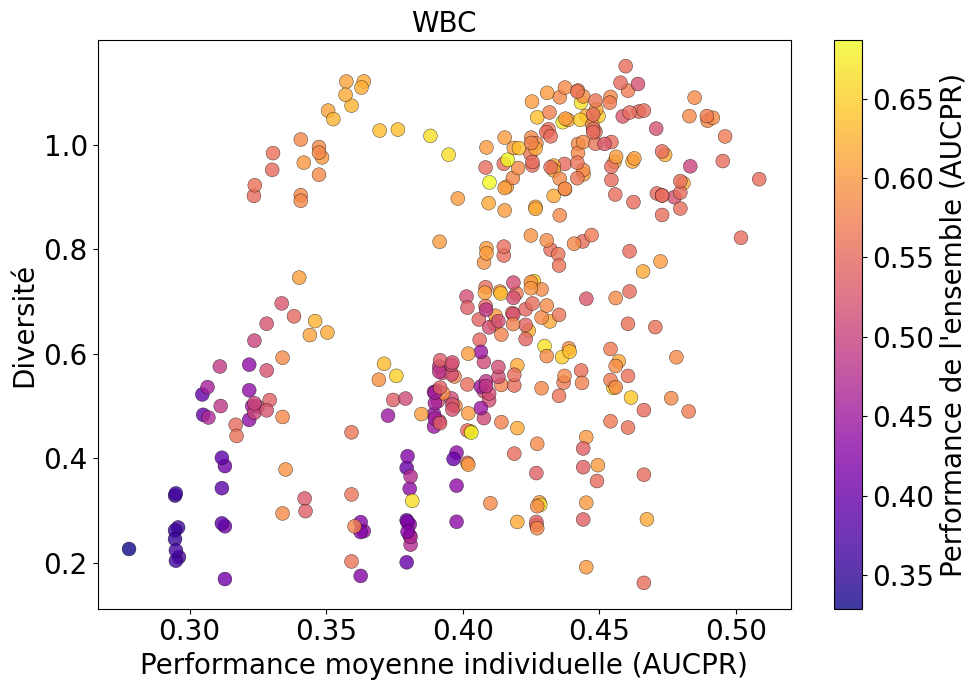

44_Wilt


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature            VIF
0  Indiv_Perf_1       1.954074
1  Indiv_Perf_2       1.314373
2  Indiv_Perf_3       1.126211
3     Diversity       2.076050
4     intercept  194792.752548


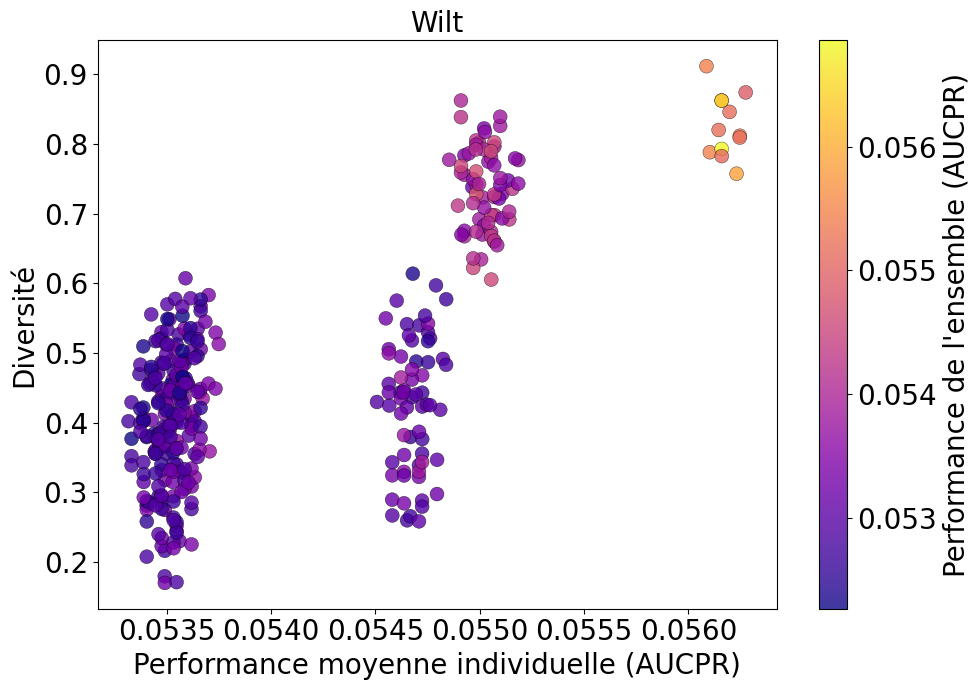

45_wine


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature        VIF
0  Indiv_Perf_1   1.312787
1  Indiv_Perf_2   1.942950
2  Indiv_Perf_3   1.423514
3     Diversity   1.345723
4     intercept  32.826280


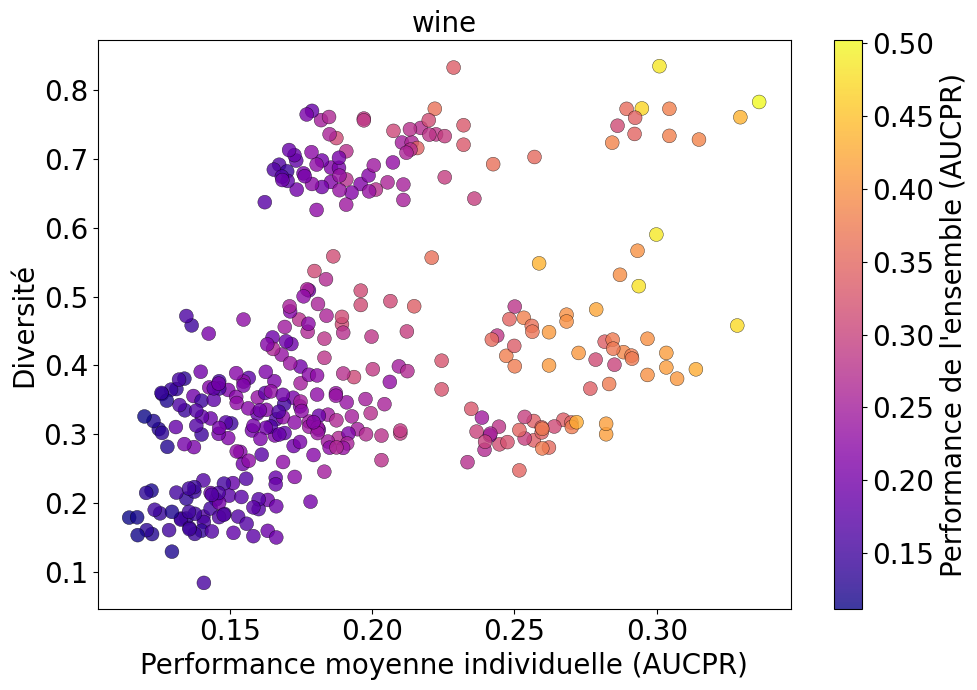

47_yeast


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


        feature           VIF
0  Indiv_Perf_1      1.744157
1  Indiv_Perf_2      1.621160
2  Indiv_Perf_3      1.266833
3     Diversity      1.616770
4     intercept  48603.548000


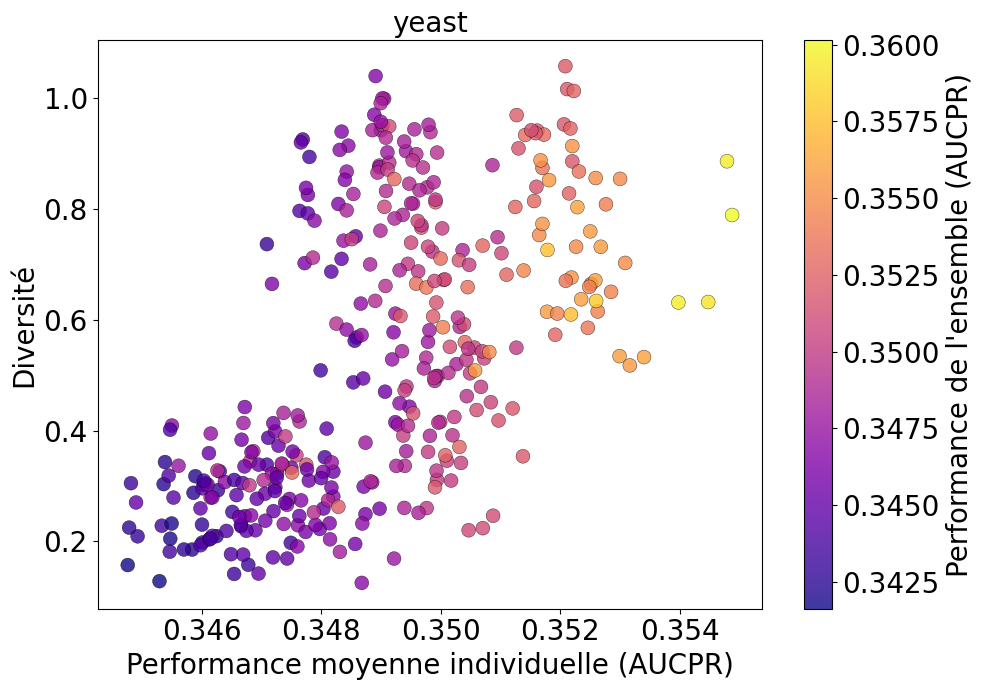

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

res = {}

for dataset in dataset_names:
    print(dataset)
    results = all_results[dataset]

    dist_matrix = 1 - compute_shap_similarity_pearson(all_results[dataset])[0]

    y_true_per_fold = {}
    scores_per_fold = {}

    valid_folds = []

    for fold in range(5):
        y_true = results["ground_truth"][fold]

        if len(np.unique(y_true)) < 2:
            continue

        valid_folds.append(fold)
        y_true_per_fold[fold] = y_true
        scores_per_fold[fold] = []

        for model_name in models_names:
            scores_per_fold[fold].append(results[model_name][fold]["predictions"])

    avg_individual_aucs = np.zeros(len(models_names))
    for i in range(len(models_names)):
        aucs = []
        for fold in valid_folds:
            auc = average_precision_score(
                y_true_per_fold[fold], scores_per_fold[fold][i]
            )
            aucs.append(auc)
        avg_individual_aucs[i] = np.nanmean(aucs)

    data_plot = []

    # Iterate through combinations of 3 models
    for combo in combinations(np.arange(len(models_names)), 3):
        combo = list(combo)

        # Retrieve performances and SORT them in descending order (Best -> Worst)
        # Indiv_Perf_1 will be the max, Indiv_Perf_3 will be the min
        current_indiv_perfs = avg_individual_aucs[combo]
        current_indiv_perfs = np.sort(current_indiv_perfs)[::-1]

        pairs = list(combinations(combo, 2))
        avg_diversity = np.mean([dist_matrix[p[0], p[1]] for p in pairs])

        ensemble_gains = []
        for fold in valid_folds:
            y_true_fold = y_true_per_fold[fold]

            current_scores = np.array([scores_per_fold[fold][m_idx] for m_idx in combo])

            ranks = np.array([rankdata(s) for s in current_scores])
            mean_ranks = np.mean(ranks, axis=0)

            ensemble_auc = average_precision_score(y_true_fold, mean_ranks)

            gain = ensemble_auc
            ensemble_gains.append(gain)

        avg_ensemble_gain = np.mean(ensemble_gains)

        # Create row entry
        row_entry = {
            "Diversity": avg_diversity,
            "Ensemble_Gain": avg_ensemble_gain,
        }

        # Dynamically add individual performances to the row
        # Because we sorted current_indiv_perfs above:
        # Indiv_Perf_1 = Best Classifier
        # Indiv_Perf_2 = Median Classifier
        # Indiv_Perf_3 = Worst Classifier
        for i, perf in enumerate(current_indiv_perfs):
            row_entry[f"Indiv_Perf_{i+1}"] = perf

        row_entry[f"Avg_Individual_Perf"] = np.mean(current_indiv_perfs)

        data_plot.append(row_entry)

    df = pd.DataFrame(data_plot)
    res[dataset] = df

    # X = df["Indiv_Perf_1", "Indiv_Perf_2", "Indiv_Perf_3"].values
    # Y = df["Diversity"].values

    # Compute VIF
    predictors = df[["Indiv_Perf_1", "Indiv_Perf_2", "Indiv_Perf_3", "Diversity"]]

    predictors["intercept"] = 1
    vif_data = pd.DataFrame()
    vif_data["feature"] = predictors.columns
    vif_data["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]

    print(vif_data)

    fig = plt.figure(figsize=(10, 7))

    # Scatter Plot
    scatter = plt.scatter(
        df["Avg_Individual_Perf"],
        df["Diversity"],
        c=df["Ensemble_Gain"],
        cmap="plasma",
        s=100,
        alpha=0.8,
        edgecolors="k",
        linewidth=0.3,
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label("Performance de l'ensemble (AUCPR)", fontsize=20)
    cbar.ax.tick_params(labelsize=20)

    plt.xlabel("Performance moyenne individuelle (AUCPR)", fontsize=20)
    plt.ylabel("Diversité", fontsize=20)
    plt.title(f"{dataset.split("_")[1]}", fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=20)

    # fig.savefig(f"img/{dataset}.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

    plt.tight_layout()
    plt.show()

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

lr_res = {}

for name, r in res.items():
    indiv_perf_cols = [c for c in r.columns if "Indiv_Perf" in c]

    X = r[indiv_perf_cols + ["Diversity"]]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    y = r["Ensemble_Gain"]

    X_scaled = sm.add_constant(X_scaled)
    model = sm.OLS(y.values, X_scaled).fit()

    params_list = [model.params[c] for c in indiv_perf_cols]
    params_list.append(model.params["Diversity"])

    lr_res[name] = params_list

In [ ]:
import pandas as pd

param_names = ["Indiv_Perf_1", "Indiv_Perf_2", "Indiv_Perf_3", "Diversity"]

df = pd.DataFrame(lr_res, index=param_names).T
df[param_names] *= 100

df["Avg_Indiv_Perf_Coef"] = df[["Indiv_Perf_1", "Indiv_Perf_2", "Indiv_Perf_3"]].mean(
    axis=1
)

df["Ratio"] = df["Diversity"] / df["Avg_Indiv_Perf_Coef"]

df.round(1)

,Indiv_Perf_1,Indiv_Perf_2,Indiv_Perf_3,Diversity,Avg_Indiv_Perf_Coef,Ratio
2_annthyroid,1.6,0.7,1.2,0.7,1.2,0.6
4_breastw,0.8,1.7,5.0,2.3,2.5,0.9
14_glass,0.8,0.7,0.1,-0.0,0.5,-0.0
15_Hepatitis,4.2,2.9,2.4,0.8,3.2,0.2
21_Lymphography,11.5,1.7,1.0,7.2,4.7,1.5
23_mammography,2.0,0.5,1.8,0.6,1.4,0.4
27_PageBlocks,2.3,1.5,2.5,2.3,2.1,1.1
29_Pima,1.2,0.3,0.6,0.2,0.7,0.2
37_Stamps,3.5,2.1,1.9,0.0,2.5,0.0
38_thyroid,1.4,1.7,4.6,2.6,2.6,1.0


In [ ]:
df.mean().round(1)

Indiv_Perf_1           2.7
Indiv_Perf_2           1.2
Indiv_Perf_3           1.6
Diversity              1.1
Avg_Indiv_Perf_Coef    1.8
Ratio                  0.5
dtype: float64

In [ ]:
from sklearn.metrics import ndcg_score
import numpy as np


i = np.array([[0, 1, 2], [2, 1, 0], [3, 4, 9]])
j = np.array([[10, 5, 0], [0, 2, 5], [9, 1, 0]])

ndcg_score(i, j)

0.6698211721902928